In [144]:
from SDP_interaction_inference.constraints import Constraint
from SDP_interaction_inference import optimization
from SDP_interaction_inference.dataset import Dataset
from SDP_interaction_inference.correlation import Correlation
from SDP_interaction_inference import utils
from SDP_interaction_inference import optimization_MOSEK
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import scipy
import tqdm
from copy import deepcopy
import matplotlib.patches
import corner
import plotly
import plotly.graph_objects as go

## Data Loading

In [38]:
# load counts
data_FIB = pd.read_csv("../../Moment-equations/Real-Data-2/Data/GSE151334_FIB_counts_thresh.csv", index_col=0)

# load capture
beta_FIB = np.loadtxt("../../Moment-equations/Real-Data-2/Capture/beta_FIB.txt")

# load cell cycle phases
phases = pd.read_csv("../R-Notebooks/Cell-Cycle/phase.csv", index_col=0)

# select FIB cells
phases_FIB = phases.loc[data_FIB.columns]

# select cells by phase: use per cell type phases
FIB_G1_mask = (phases_FIB['Phase_per_type'] == "G1")
FIB_S_mask = (phases_FIB['Phase_per_type'] == "S")
FIB_G2M_mask = (phases_FIB['Phase_per_type'] == "G2M")

# separate data by phase
data_FIB_G1 = data_FIB.loc[:, FIB_G1_mask]
data_FIB_S = data_FIB.loc[:, FIB_S_mask]
data_FIB_G2M = data_FIB.loc[:, FIB_G2M_mask]

# separate capture by phase
beta_FIB_G1 = beta_FIB[FIB_G1_mask]
beta_FIB_S = beta_FIB[FIB_S_mask]
beta_FIB_G2M = beta_FIB[FIB_G2M_mask]

# amounts
print(f"Total cells = {beta_FIB.size}")
print(f"Cell in phase \nG1 = {beta_FIB_G1.size} \nS = {beta_FIB_S.size} \nG2M = {beta_FIB_G2M.size}")

Total cells = 277
Cell in phase 
G1 = 39 
S = 108 
G2M = 130


In [47]:
# load RNA types
biotypes_dict = json.load(open("../../Moment-equations/Real-Data-2/Biotypes/biotypes_FIB.json"))

# select indices of protein coding mRNA and non-coding miRNA
pcRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "protein_coding"]
miRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "miRNA"]

# select protein coding genes
data_FIB_G1_pcRNA = data_FIB_G1.iloc[pcRNA_indices]
data_FIB_S_pcRNA = data_FIB_S.iloc[pcRNA_indices]
data_FIB_G2M_pcRNA = data_FIB_G2M.iloc[pcRNA_indices]

# select protein coding genes
data_FIB_G1_miRNA = data_FIB_G1.iloc[miRNA_indices]
data_FIB_S_miRNA = data_FIB_S.iloc[miRNA_indices]
data_FIB_G2M_miRNA = data_FIB_G2M.iloc[miRNA_indices]

# amounts: see './Biotypes/biotypes.ipynb' for full pie chart of types
print(f"Total genes = {data_FIB.shape[0]}")
print(f"Genes of type \nprotein coding = {len(pcRNA_indices)} \nmicro RNA = {len(miRNA_indices)}")

Total genes = 11747
Genes of type 
protein coding = 9296 
micro RNA = 19


## Analysis setup

In [133]:
def construct_dataset(mirna_sample, mrna_dataset, beta, resamples=1000):

    # size
    gene_pairs, cells = mrna_dataset.shape

    # construct paired count dataframe
    counts_df = pd.DataFrame(
        index = [f"Gene-pair-{i}" for i in range(gene_pairs)],
        columns = [f"Cell-{j}" for j in range(cells)]
    )

    # fill with pairs
    for i in range(gene_pairs):
        gene_i = mirna_sample
        gene_j = mrna_dataset.iloc[i]
        gene_pair_ij = list(zip(gene_i, gene_j))
        counts_df.iloc[i] = gene_pair_ij

    # construct dataset object
    data = Dataset()
    data.count_dataset = counts_df
    data.cells = cells
    data.gene_pairs = gene_pairs

    # settings
    data.resamples = resamples

    # set capture
    data.beta = beta

    return data

In [134]:
def model_free_independence_test(dataset, d, **kwargs):

    # Independent model free
    constraints = Constraint(
        moment_bounds=True,
        moment_matrices=True,
        factorization=True
    )
    opt_MF_ind = optimization.ModelFreeOptimization(dataset, d_bd=d, d_me=0, d_sd=d, constraints=constraints, printing=False, silent=True, **kwargs)
    opt_MF_ind.analyse_dataset()

    # extract results
    status = [solution['status'] for solution in opt_MF_ind.result_dict.values()]
    times  = [solution['time'] for solution in opt_MF_ind.result_dict.values()]
    cuts   = [solution['cuts'] for solution in opt_MF_ind.result_dict.values()]

    # collect
    data = {
        'status': status,
        'times': times,
        'cuts': cuts
    }

    return data

In [135]:
def model_free_interacting_test(dataset, d, **kwargs):

    # Interacting model free
    constraints = Constraint(
        moment_bounds=True,
        moment_matrices=True,
        factorization=False
    )
    opt_MF_int = optimization.ModelFreeOptimization(dataset, d_bd=d, d_me=0, d_sd=d, constraints=constraints, printing=False, silent=True, **kwargs)
    opt_MF_int.analyse_dataset()

    # extract results
    status = [solution['status'] for solution in opt_MF_int.result_dict.values()]
    times  = [solution['time'] for solution in opt_MF_int.result_dict.values()]
    cuts   = [solution['cuts'] for solution in opt_MF_int.result_dict.values()]
    correlation = [solution['correlation'] for solution in opt_MF_int.result_dict.values()]

    # collect
    data = {
        'status': status,
        'times': times,
        'cuts': cuts,
        'correlation': correlation
    }

    return data

In [146]:
def model_free_interacting_test_HAR(dataset, d, N, **kwargs):

    # MF int HAR
    opt_har = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, N=N, **kwargs)
    opt_har.analyse_dataset()

    # extract results
    opt_correlation = []
    min_correlation = []
    max_correlation = []
    for i in range(dataset.gene_pairs):
        opt_correlation.append(opt_har.result_dict_optimization[i]['feasible_correlations'][0])
        har_correlations = opt_har.result_dict_HAR[i]['feasible_correlations']
        min_correlation.append(np.min(har_correlations))
        max_correlation.append(np.max(har_correlations))

    # collect
    data = {
        'opt_correlation': opt_correlation,
        'min_correlation': min_correlation,
        'max_correlation': max_correlation
    }

    return data

In [137]:
def model_free_interacting_test_RND(dataset, d, N, **kwargs):

    # MF int random linear objectives
    opt_rnd = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, method_opt="random", N=N)
    opt_rnd.analyse_dataset()

    # extract results
    min_correlation = []
    max_correlation = []
    for i in range(dataset.gene_pairs):
        har_correlations = opt_rnd.result_dict_optimization[i]['feasible_correlations']
        min_correlation.append(np.min(har_correlations))
        max_correlation.append(np.max(har_correlations))

    # collect
    data = {
        'min_correlation': min_correlation,
        'max_correlation': max_correlation
    }

    return data

In [138]:
def correlation_bootstrap_sample(sample, beta, confidence=None, resamples=None):

    # get sample size
    n = sample.shape[0]

    # get bootstrap size: default to sample size
    if resamples is None:
        resamples = n
    # confidence level: default to 95%
    if confidence is None:
        confidence = 0.95

    # initialize random generator
    rng = np.random.default_rng()

    # bootstrap to N x n x 2 array
    boot = rng.choice(sample, size=(resamples, n))

    # capture moments
    E_beta = np.mean(beta)
    E_beta2 = np.mean(beta**2)

    # compute correlations
    estimates = np.zeros(resamples)
    for i in range(resamples):

        b1 = boot[i, :, 0]
        b2 = boot[i, :, 1]

        # OB moments
        E_xy_OB = np.mean(b1 * b2)
        E_x_OB = np.mean(b1)
        E_y_OB = np.mean(b2)
        E_x2_OB = np.mean(b1**2)
        E_y2_OB = np.mean(b2**2)

        # OG moments
        E_xy_OG = E_xy_OB / E_beta2
        E_x_OG = E_x_OB / E_beta
        E_y_OG = E_y_OB / E_beta
        E_x2_OG = (1 / E_beta2)*E_x2_OB + (1 / E_beta)*E_x_OB - (1 / E_beta2)*E_x_OB
        E_y2_OG = (1 / E_beta2)*E_y2_OB + (1 / E_beta)*E_y_OB - (1 / E_beta2)*E_y_OB

        varx_OG = E_x2_OG - E_x_OG**2
        vary_OG = E_y2_OG - E_y_OG**2

        if varx_OG <= 0.0 or vary_OG <= 0.0:
            corr = np.nan
        else:
            corr = (E_xy_OG - E_x_OG*E_y_OG) / (np.sqrt(varx_OG) * np.sqrt(vary_OG))

        estimates[i] = corr

    # take quantiles
    alpha = 1 - confidence
    interval = np.quantile(estimates, [(alpha / 2), 1 - (alpha / 2)])

    # compute point estimate from original sample
    b1 = sample[:, 0]
    b2 = sample[:, 1]

    # OB moments
    E_xy_OB = np.mean(b1 * b2)
    E_x_OB = np.mean(b1)
    E_y_OB = np.mean(b2)
    E_x2_OB = np.mean(b1**2)
    E_y2_OB = np.mean(b2**2)

    # OG moments
    E_xy_OG = E_xy_OB / E_beta2
    E_x_OG = E_x_OB / E_beta
    E_y_OG = E_y_OB / E_beta
    E_x2_OG = (1 / E_beta2)*E_x2_OB + (1 / E_beta)*E_x_OB - (1 / E_beta2)*E_x_OB
    E_y2_OG = (1 / E_beta2)*E_y2_OB + (1 / E_beta)*E_y_OB - (1 / E_beta2)*E_y_OB

    varx_OG = E_x2_OG - E_x_OG**2
    vary_OG = E_y2_OG - E_y_OG**2

    if varx_OG <= 0.0 or vary_OG <= 0.0:
        corr = np.nan
    else:
        corr = (E_xy_OG - E_x_OG*E_y_OG) / (np.sqrt(varx_OG) * np.sqrt(vary_OG))

    # collect results
    result = np.array([
        corr,
        interval[0],
        interval[1]
    ])

    return result

In [139]:
def correlation_bootstrap_dataset(dataset, confidence=None, resamples=None):
    '''Bootstrap dataset correlations.'''

    # record results
    results = np.empty((dataset.gene_pairs, 3))
    
    # bootstrap
    for i in tqdm.tqdm(range(dataset.gene_pairs)):
        results[i, :] = correlation_bootstrap_sample(np.array([*dataset.count_dataset.iloc[i].values]), np.ones(dataset.cells), confidence, resamples)

    return results

In [140]:
def analytic_correlation_bootstrap_dataset(dataset, confidence=None, resamples=None):
    '''Bootstrap dataset correlations adjusted for capture efficiency.'''

    # record results
    results = np.empty((dataset.gene_pairs, 3))
    
    # bootstrap
    for i in tqdm.tqdm(range(dataset.gene_pairs)):
        results[i, :] = correlation_bootstrap_sample(np.array([*dataset.count_dataset.iloc[i].values]), dataset.beta, confidence, resamples)

    return results

## Analysis

In [157]:
# select mRNA
G = 100
mRNA = data_FIB_G1_pcRNA.index[:G]

# dataframe to store model free results
MF_independent_df = pd.DataFrame(
    index=mRNA
)
MF_interacting_df = pd.DataFrame(
    index=mRNA
)

In [158]:
# select miRNA
miRNA = "MIR199A1"

# settings
d = 3
N = 1000
confidence = 0.95
time_limit = 30
total_time_limit = 30
cut_limit = 100

# get datasets
data_miRNA_list = [data_FIB_G1_miRNA, data_FIB_S_miRNA, data_FIB_G2M_miRNA]
data_pcRNA_list = [data_FIB_G1_pcRNA, data_FIB_S_pcRNA, data_FIB_G2M_pcRNA]
beta_list = [beta_FIB_G1, beta_FIB_S, beta_FIB_G2M]

# for each phase
for i, phase in enumerate(["G1", "S", "G2M"]):

    # display day
    print(f"\nRunning {phase} phase")

    # construct dataset of miRNA paired with mRNA
    dataset_SDP = construct_dataset(data_miRNA_list[i].loc[miRNA], data_pcRNA_list[i].loc[mRNA], beta_list[i])

    # bootstrap
    print("Bootstrap:")
    dataset_SDP.confidence = confidence
    dataset_SDP.bootstrap(d=d, tqdm_disable=False)

    # independence test
    print("Model Free Independence")
    MF_ind = model_free_independence_test(dataset_SDP, d, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit)

    # display results
    print(np.unique(MF_ind['status'], return_counts=True))

    # interacting tests
    print("Model Free Interacting")
    MF_int_cut = model_free_interacting_test(dataset_SDP, d, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit)
    MF_int_har = model_free_interacting_test_HAR(dataset_SDP, d, N)
    MF_int_rnd = model_free_interacting_test_RND(dataset_SDP, d, N)

    # correlation bootstraps
    print("Correlation Bootstraps")
    observed_correlation = correlation_bootstrap_dataset(dataset_SDP, confidence=confidence)
    analytic_correlation = analytic_correlation_bootstrap_dataset(dataset_SDP, confidence=confidence)

    # store results on dataframe
    MF_independent_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_status'] = MF_ind['status']

    MF_interacting_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_cut'] = MF_int_cut['correlation']
    MF_interacting_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_MOSEK'] = MF_int_har['opt_correlation']
    MF_interacting_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_HAR_min'] = MF_int_har['min_correlation']
    MF_interacting_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_HAR_max'] = MF_int_har['max_correlation']
    MF_interacting_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_RND_min'] = MF_int_rnd['min_correlation']
    MF_interacting_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_RND_max'] = MF_int_rnd['max_correlation']

    MF_interacting_df[f'{miRNA}_{phase}_c{int(100*confidence)}_corr_OB'] = observed_correlation[:, 0]
    MF_interacting_df[f'{miRNA}_{phase}_c{int(100*confidence)}_corr_OB_min'] = observed_correlation[:, 1]
    MF_interacting_df[f'{miRNA}_{phase}_c{int(100*confidence)}_corr_OB_max'] = observed_correlation[:, 2]
    MF_interacting_df[f'{miRNA}_{phase}_c{int(100*confidence)}_corr_AL'] = analytic_correlation[:, 0]
    MF_interacting_df[f'{miRNA}_{phase}_c{int(100*confidence)}_corr_AL_min'] = analytic_correlation[:, 1]
    MF_interacting_df[f'{miRNA}_{phase}_c{int(100*confidence)}_corr_AL_max'] = analytic_correlation[:, 2]

    # save dataframe
    MF_independent_df.to_csv("Results/independent_MF.csv")
    MF_interacting_df.to_csv("Results/interacting_MF.csv")


Running G1 phase
Bootstrap:


100%|██████████| 100/100 [00:00<00:00, 253.81it/s]


Model Free Independence


100%|██████████| 100/100 [00:04<00:00, 23.48it/s]


(array(['CUT_LIMIT', 'OPTIMAL'], dtype='<U9'), array([ 1, 99]))
Model Free Interacting


...

 32%|███▏      | 32/100 [01:27<03:15,  2.88s/it]c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_utils.py:688: RuntimeWarning:

invalid value encountered in sqrt

 96%|█████████▌| 96/100 [04:38<00:12,  3.07s/it]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 95, in analyse_dataset
    feasible_points = self.MOSEK_feasible_points(i)
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 226, in MOSEK_feasible_points
    feasible_points.append(y.level())
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\mosek\fusion\impl\_implementation.py", line 15579, in level
    return self._level_(*args)
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\mosek\fusion\impl\_implementation.py", line 16828, in _level_
 

Optimization failed: Solution status is Undefined but Optimal is expected. Reason: Accessing interior-point solution whose problem status is PrimalInfeasible.
Optimization failed: Solution status is Undefined but Optimal is expected. Reason: Accessing interior-point solution whose problem status is PrimalInfeasible.


100%|██████████| 100/100 [04:45<00:00,  2.85s/it]


Correlation Bootstraps


100%|██████████| 100/100 [00:00<00:00, 173.82it/s]


In [159]:
MF_independent_df.head()

,MIR199A1_G1_d3_c95_status,MIR199A1_S_d3_c95_status,MIR199A1_G2M_d3_c95_status
A4GALT,OPTIMAL,INFEASIBLE,OPTIMAL
AAAS,OPTIMAL,OPTIMAL,OPTIMAL
AACS,OPTIMAL,OPTIMAL,INFEASIBLE
AADAT,OPTIMAL,OPTIMAL,INFEASIBLE
AAGAB,OPTIMAL,OPTIMAL,OPTIMAL


In [161]:
MF_interacting_df.head()

,MIR199A1_G1_d3_c95_corr_cut,MIR199A1_G1_d3_c95_corr_MOSEK,MIR199A1_G1_d3_c95_corr_HAR_min,MIR199A1_G1_d3_c95_corr_HAR_max,MIR199A1_G1_d3_c95_corr_RND_min,MIR199A1_G1_d3_c95_corr_RND_max,MIR199A1_G1_c95_corr_OB,MIR199A1_G1_c95_corr_OB_min,MIR199A1_G1_c95_corr_OB_max,MIR199A1_G1_c95_corr_AL,...,MIR199A1_G2M_d3_c95_corr_HAR_min,MIR199A1_G2M_d3_c95_corr_HAR_max,MIR199A1_G2M_d3_c95_corr_RND_min,MIR199A1_G2M_d3_c95_corr_RND_max,MIR199A1_G2M_c95_corr_OB,MIR199A1_G2M_c95_corr_OB_min,MIR199A1_G2M_c95_corr_OB_max,MIR199A1_G2M_c95_corr_AL,MIR199A1_G2M_c95_corr_AL_min,MIR199A1_G2M_c95_corr_AL_max
A4GALT,None,-0.632785,-0.999703,-0.183128,-1.000000,0.999986,-0.049254,NaN,NaN,-0.072688,...,-0.998052,0.345792,-1.0,1.127660,0.066012,-0.051864,0.606840,0.054229,-0.092846,0.557758
AAAS,None,-0.683858,-0.683858,-0.683858,-1.000000,-0.000276,-0.034954,NaN,NaN,-0.048168,...,-0.238915,0.338698,-1.0,1.000000,0.097141,-0.102416,0.291186,0.068028,-0.156315,0.259458
AACS,None,-0.609421,-0.999896,-0.164924,-0.999999,0.999998,-0.042684,NaN,NaN,-0.067729,...,-0.998490,-0.053965,-1.0,0.087480,-0.053273,-0.089978,0.002579,-0.088722,-0.141192,-0.033234
AADAT,None,-0.722797,-0.722797,-0.722797,-1.000000,-0.000508,-0.069338,NaN,NaN,-0.099356,...,-0.997078,-0.184640,-1.0,-0.303306,-0.053954,-0.084414,-0.033948,-0.084469,-0.125001,-0.050667
AAGAB,None,-0.551162,-0.998593,-0.303745,-1.000000,0.947362,-0.094777,NaN,NaN,-0.141207,...,-0.734992,0.086875,-1.0,1.000000,0.039044,-0.072762,0.367938,0.008766,-0.090771,0.358306


# Plots

## Independence test

In [76]:
import plotly.express as px

In [113]:
def add_clr_constructor(phase):
    
    def add_clr(row):
        status = row[f'MIR199A1_{phase}_d3_t30_ct100_c95_status']
        if status == "OPTIMAL":
            return 0
        elif status == "INFEASIBLE":
            return 1
        else:
            return 2

    return add_clr    

In [121]:
columns = ['MIR199A1_G1_d3_t30_ct100_c95_status', 'MIR199A1_S_d3_t30_ct100_c95_status', 'MIR199A1_G2M_d3_t30_ct100_c95_status']
labels = {col: phase for col, phase in zip(columns, ["G1", "S", "G2M"])}
df = MF_independent_df[columns]
df['clr'] = df.apply(add_clr_constructor("S"), axis=1)

fig = px.parallel_categories(df, dimensions=columns, labels=labels, color='clr')

C:\Users\willi\AppData\Local\Temp\ipykernel_21856\940436319.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [122]:
fig.show()

## Interacting test & Correlations

In [165]:
MF_interacting_df.head()

,MIR199A1_G1_d3_c95_corr_cut,MIR199A1_G1_d3_c95_corr_MOSEK,MIR199A1_G1_d3_c95_corr_HAR_min,MIR199A1_G1_d3_c95_corr_HAR_max,MIR199A1_G1_d3_c95_corr_RND_min,MIR199A1_G1_d3_c95_corr_RND_max,MIR199A1_G1_c95_corr_OB,MIR199A1_G1_c95_corr_OB_min,MIR199A1_G1_c95_corr_OB_max,MIR199A1_G1_c95_corr_AL,...,MIR199A1_G2M_d3_c95_corr_HAR_min,MIR199A1_G2M_d3_c95_corr_HAR_max,MIR199A1_G2M_d3_c95_corr_RND_min,MIR199A1_G2M_d3_c95_corr_RND_max,MIR199A1_G2M_c95_corr_OB,MIR199A1_G2M_c95_corr_OB_min,MIR199A1_G2M_c95_corr_OB_max,MIR199A1_G2M_c95_corr_AL,MIR199A1_G2M_c95_corr_AL_min,MIR199A1_G2M_c95_corr_AL_max
A4GALT,None,-0.632785,-0.999703,-0.183128,-1.000000,0.999986,-0.049254,NaN,NaN,-0.072688,...,-0.998052,0.345792,-1.0,1.127660,0.066012,-0.051864,0.606840,0.054229,-0.092846,0.557758
AAAS,None,-0.683858,-0.683858,-0.683858,-1.000000,-0.000276,-0.034954,NaN,NaN,-0.048168,...,-0.238915,0.338698,-1.0,1.000000,0.097141,-0.102416,0.291186,0.068028,-0.156315,0.259458
AACS,None,-0.609421,-0.999896,-0.164924,-0.999999,0.999998,-0.042684,NaN,NaN,-0.067729,...,-0.998490,-0.053965,-1.0,0.087480,-0.053273,-0.089978,0.002579,-0.088722,-0.141192,-0.033234
AADAT,None,-0.722797,-0.722797,-0.722797,-1.000000,-0.000508,-0.069338,NaN,NaN,-0.099356,...,-0.997078,-0.184640,-1.0,-0.303306,-0.053954,-0.084414,-0.033948,-0.084469,-0.125001,-0.050667
AAGAB,None,-0.551162,-0.998593,-0.303745,-1.000000,0.947362,-0.094777,NaN,NaN,-0.141207,...,-0.734992,0.086875,-1.0,1.000000,0.039044,-0.072762,0.367938,0.008766,-0.090771,0.358306


Text(0.5, 1.0, 'Correlation across cell cycle phases')

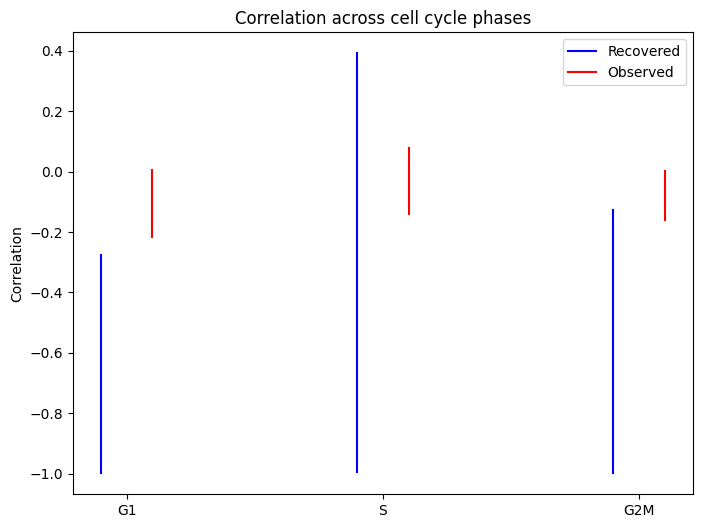

In [206]:
g = 6
mRNA_name = mRNA[g]

fig, axs = plt.subplots(figsize=(8, 6))
labels = ["G1", "S", "G2M"]

for i, phase in enumerate(labels):
    axs.plot(
        [i - 0.1] * 2,
        [
            MF_interacting_df.loc[mRNA_name, f"{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_HAR_min"],
            MF_interacting_df.loc[mRNA_name, f"{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_HAR_max"]
        ],
        color="blue",
        label="Recovered" if i == 0 else None
    )
    axs.plot(
        [i + 0.1] * 2,
        [
            MF_interacting_df.loc[mRNA_name, f"{miRNA}_{phase}_c{int(100*confidence)}_corr_OB_min"],
            MF_interacting_df.loc[mRNA_name, f"{miRNA}_{phase}_c{int(100*confidence)}_corr_OB_max"]
        ],
        color="red",
        label="Observed" if i == 0 else None
    )

axs.set_xticks(range(3), labels=labels)
axs.legend()
axs.set_ylabel("Correlation")
axs.set_title("Correlation across cell cycle phases")

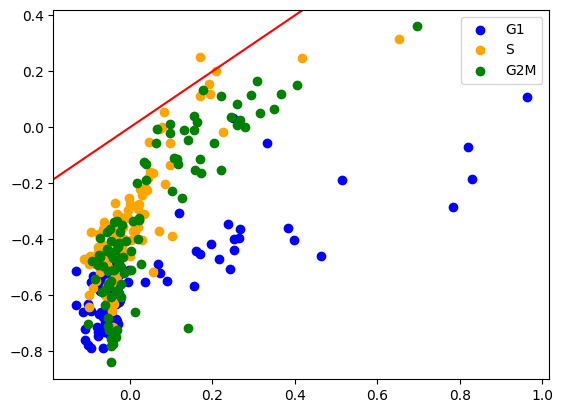

In [181]:
colours = ["blue", "orange", "green"]
labels = ["G1", "S", "G2M"]
for phase, colour in zip(labels, colours):
    plt.scatter(
        MF_interacting_df[f"{miRNA}_{phase}_c{int(100*confidence)}_corr_OB"],
        MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_MOSEK"],
        color=colour,
        label=phase
    )
plt.axline([0, 0], [0.01, 0.01], color="red")
plt.legend()

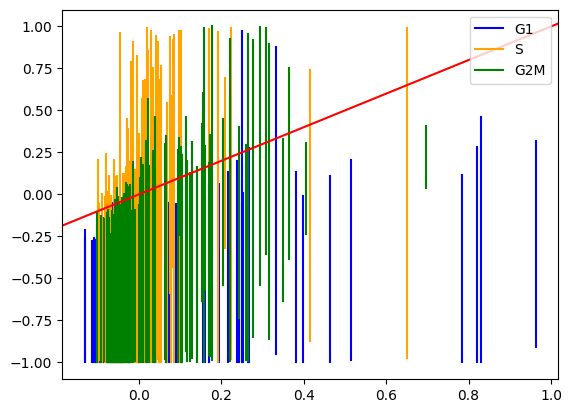

In [184]:
colours = ["blue", "orange", "green"]
labels = ["G1", "S", "G2M"]
for phase, colour in zip(labels, colours):
    corr_OB = MF_interacting_df[f"{miRNA}_{phase}_c{int(100*confidence)}_corr_OB"]
    corr_OG_min = MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_HAR_min"]
    corr_OG_max = MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_HAR_max"]
    label=phase
    for ob, mn, mx in zip(corr_OB, corr_OG_min, corr_OG_max):
        plt.plot([ob, ob], [mn, mx], color=colour, label=label)
        label=None
plt.axline([0, 0], [0.01, 0.01], color="red")
plt.legend()